In [7]:
# Step 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 读取整理好的分析数据
df_analysis = pd.read_csv("naplan_analysis_ready.csv")

print(df_analysis.head())
print(df_analysis.shape)
print(df_analysis.columns.tolist())

   year  year_level      state       attribute        subgroup  \
0  2023           3  Australia  ABS remoteness  Inner regional   
1  2023           3  Australia  ABS remoteness    Major cities   
2  2023           3  Australia  ABS remoteness  Outer regional   
3  2023           3  Australia  ABS remoteness          Remote   
4  2023           3  Australia  ABS remoteness     Very remote   

   grammar_punctuation_nas  numeracy_nas  reading_nas  spelling_nas  \
0                17.188876     11.677124    11.317540     14.917759   
1                10.553130      8.169079     7.117291      8.679344   
2                21.895964     16.147196    15.357964     18.214257   
3                32.400297     26.688135    24.478573     28.109983   
4                58.334510     54.220183    49.044092     53.316867   

   writing_nas  
0     7.528938  
1     4.607834  
2    10.651390  
3    20.262246  
4    46.139732  
(2414, 10)
['year', 'year_level', 'state', 'attribute', 'subgroup', 'gramm

In [9]:
# Step 2
# 检查缺失
print(df_analysis.isna().sum())

# 检查数值列
analysis_cols = [
    "reading_nas",
    "writing_nas",
    "spelling_nas",
    "grammar_punctuation_nas",
    "numeracy_nas"
]

print(df_analysis[analysis_cols].describe())

year                       0
year_level                 0
state                      0
attribute                  0
subgroup                   0
grammar_punctuation_nas    0
numeracy_nas               0
reading_nas                0
spelling_nas               0
writing_nas                0
dtype: int64
       reading_nas  writing_nas  spelling_nas  grammar_punctuation_nas  \
count  2414.000000  2414.000000   2414.000000              2414.000000   
mean     16.662686    16.555307     15.398459                21.609820   
std      13.836106    14.456427     13.189998                15.311582   
min       1.216885     1.165098      1.872541                 2.241307   
25%       7.954043     7.205329      7.429058                11.323128   
50%      12.431954    12.295058     11.278676                16.974929   
75%      20.136604    20.261508     18.092404                27.205577   
max      85.625000    89.046053     85.756579                90.296053   

       numeracy_nas  
count   

In [11]:
# Step 3: 相关性分析
corr_cols = [
    "reading_nas",
    "writing_nas",
    "spelling_nas",
    "grammar_punctuation_nas",
    "numeracy_nas"
]

corr_matrix = df_analysis[corr_cols].corr(method="pearson")

print(corr_matrix)

                         reading_nas  writing_nas  spelling_nas  \
reading_nas                 1.000000     0.957544      0.965846   
writing_nas                 0.957544     1.000000      0.914904   
spelling_nas                0.965846     0.914904      1.000000   
grammar_punctuation_nas     0.987400     0.934489      0.960539   
numeracy_nas                0.987467     0.965613      0.961295   

                         grammar_punctuation_nas  numeracy_nas  
reading_nas                             0.987400      0.987467  
writing_nas                             0.934489      0.965613  
spelling_nas                            0.960539      0.961295  
grammar_punctuation_nas                 1.000000      0.976850  
numeracy_nas                            0.976850      1.000000  


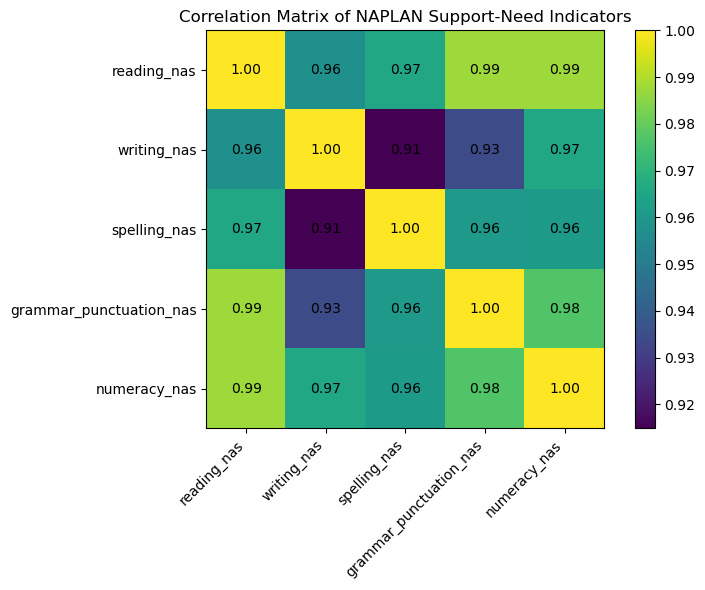

In [13]:
# Step 4: 相关矩阵热图
plt.figure(figsize=(8, 6))
plt.imshow(corr_matrix, interpolation="nearest")
plt.colorbar()

plt.xticks(range(len(corr_cols)), corr_cols, rotation=45, ha="right")
plt.yticks(range(len(corr_cols)), corr_cols)

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Correlation Matrix of NAPLAN Support-Need Indicators")
plt.tight_layout()
plt.show()

In [15]:
# Step 5：单独看 reading 和其他变量的关系
reading_corr = corr_matrix["reading_nas"].sort_values(ascending=False)
print(reading_corr)

reading_nas                1.000000
numeracy_nas               0.987467
grammar_punctuation_nas    0.987400
spelling_nas               0.965846
writing_nas                0.957544
Name: reading_nas, dtype: float64


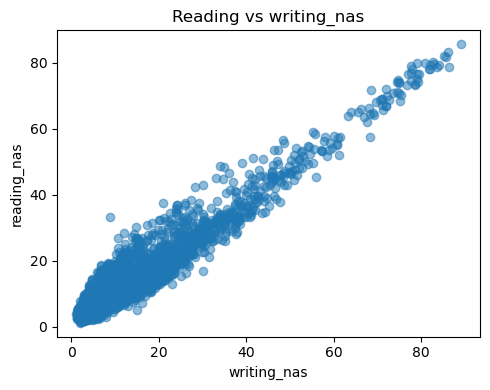

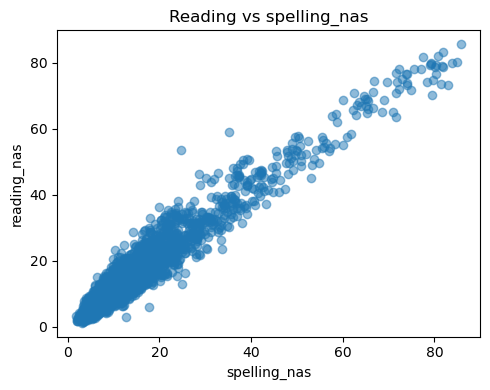

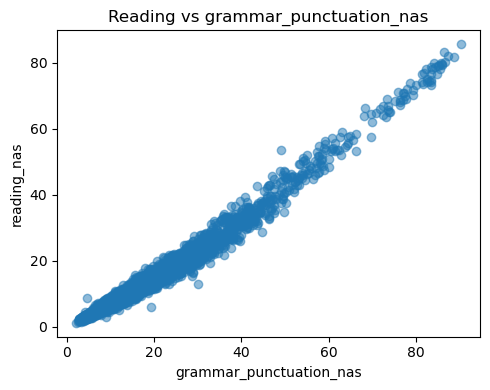

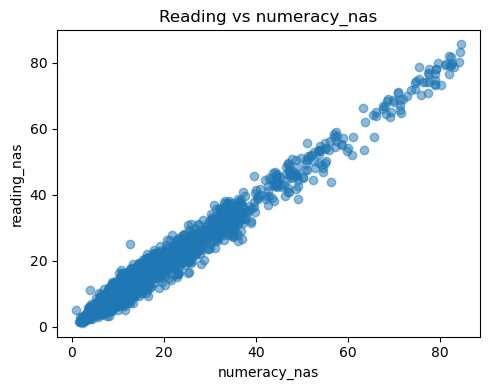

In [17]:
# Step 6: 散点图
compare_cols = [
    "writing_nas",
    "spelling_nas",
    "grammar_punctuation_nas",
    "numeracy_nas"
]

for col in compare_cols:
    plt.figure(figsize=(5, 4))
    plt.scatter(df_analysis[col], df_analysis["reading_nas"], alpha=0.5)
    plt.xlabel(col)
    plt.ylabel("reading_nas")
    plt.title(f"Reading vs {col}")
    plt.tight_layout()
    plt.show()

In [19]:
# Step 7 相关性分析
import statsmodels.api as sm

# 自变量
X = df_analysis[[
    "writing_nas",
    "spelling_nas",
    "grammar_punctuation_nas",
    "numeracy_nas"
]]

# 因变量
y = df_analysis["reading_nas"]

# 加截距
X = sm.add_constant(X)

# 拟合模型
model = sm.OLS(y, X).fit()

# 输出结果
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            reading_nas   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                 5.082e+04
Date:                Sat, 11 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:46:26   Log-Likelihood:                -4399.4
No. Observations:                2414   AIC:                             8809.
Df Residuals:                    2409   BIC:                             8838.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [21]:
# 聚类
# Step 1 准备聚类数据
from sklearn.preprocessing import StandardScaler

cluster_cols = [
    "reading_nas",
    "writing_nas",
    "spelling_nas",
    "grammar_punctuation_nas",
    "numeracy_nas"
]

X = df_analysis[cluster_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X.shape)

(2414, 5)


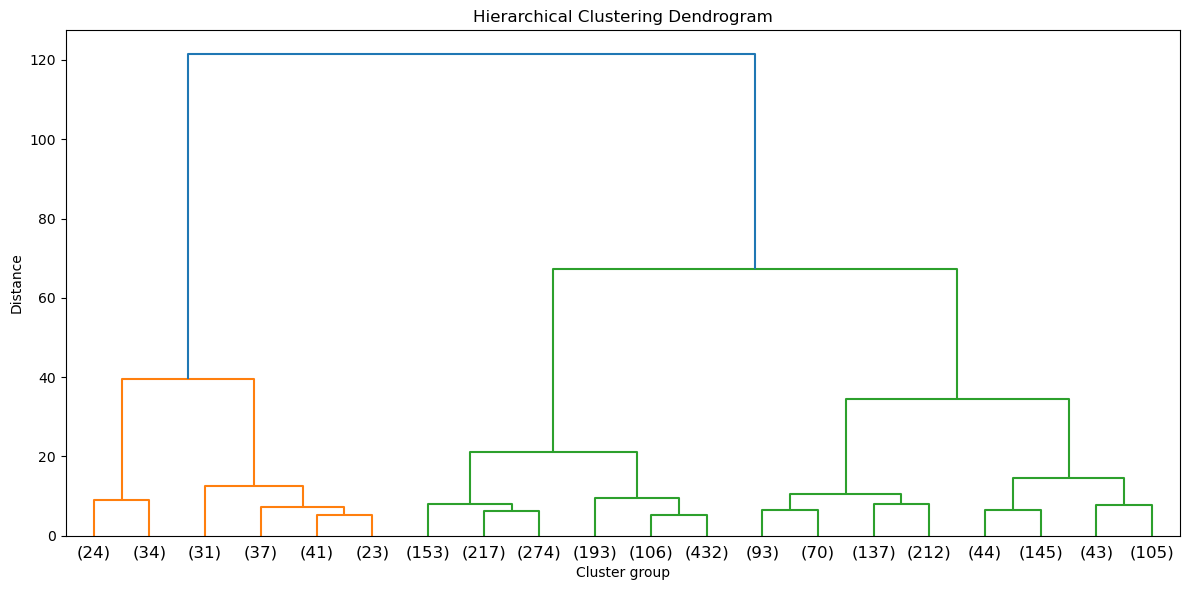

In [23]:
# Step 2 Hierarchical clustering
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode="lastp", p=20)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Cluster group")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

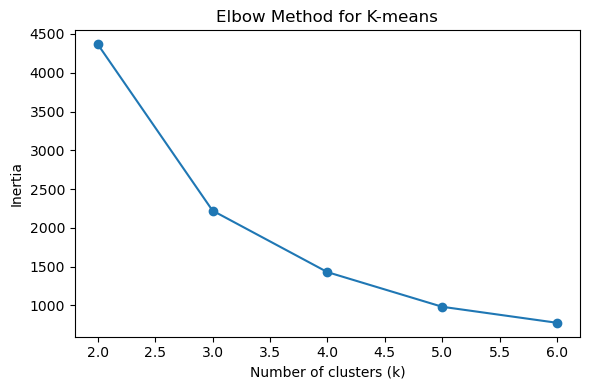

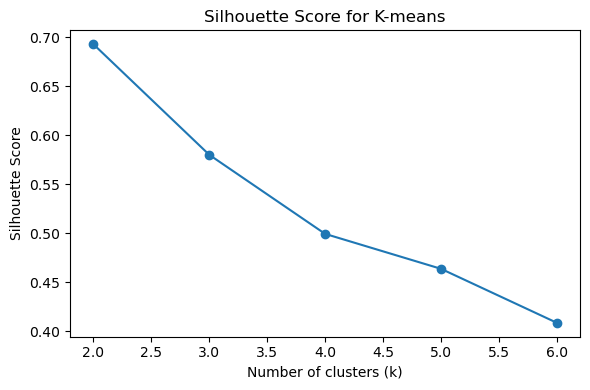

Silhouette scores:
k=2: 0.6930
k=3: 0.5802
k=4: 0.4995
k=5: 0.4638
k=6: 0.4087


In [27]:
# Step 3 K-means
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
k_values = range(2, 7)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Elbow plot
plt.figure(figsize=(6, 4))
plt.plot(list(k_values), inertias, marker="o")
plt.title("Elbow Method for K-means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.tight_layout()
plt.show()

# Silhouette plot
plt.figure(figsize=(6, 4))
plt.plot(list(k_values), sil_scores, marker="o")
plt.title("Silhouette Score for K-means")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

print("Silhouette scores:")
for k, score in zip(k_values, sil_scores):
    print(f"k={k}: {score:.4f}")

In [29]:
# Step 4
from sklearn.cluster import KMeans

# 先试 k=2
k2 = KMeans(n_clusters=2, random_state=42, n_init=10)
df_analysis["cluster_k2"] = k2.fit_predict(X_scaled)

print(df_analysis["cluster_k2"].value_counts().sort_index())

cluster_k2
0    2075
1     339
Name: count, dtype: int64


In [31]:
cluster_cols = [
    "reading_nas",
    "writing_nas",
    "spelling_nas",
    "grammar_punctuation_nas",
    "numeracy_nas"
]

cluster_profile_k2 = df_analysis.groupby("cluster_k2")[cluster_cols].mean().round(2)
print(cluster_profile_k2)

            reading_nas  writing_nas  spelling_nas  grammar_punctuation_nas  \
cluster_k2                                                                    
0                 12.14        11.93         11.22                    16.69   
1                 44.34        44.86         40.95                    51.73   

            numeracy_nas  
cluster_k2                
0                  12.24  
1                  45.95  


In [33]:
cluster_centers_k2 = pd.DataFrame(
    k2.cluster_centers_,
    columns=cluster_cols
).round(2)

print(cluster_centers_k2)

   reading_nas  writing_nas  spelling_nas  grammar_punctuation_nas  \
0        -0.33        -0.32         -0.32                    -0.32   
1         2.00         1.96          1.94                     1.97   

   numeracy_nas  
0         -0.33  
1          2.02  


In [35]:
# Step 5: K=3
# 再试 k=3
k3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_analysis["cluster_k3"] = k3.fit_predict(X_scaled)

print(df_analysis["cluster_k3"].value_counts().sort_index())

cluster_k3
0     571
1     146
2    1697
Name: count, dtype: int64


In [37]:
cluster_profile_k3 = df_analysis.groupby("cluster_k3")[cluster_cols].mean().round(2)
print(cluster_profile_k3)

            reading_nas  writing_nas  spelling_nas  grammar_punctuation_nas  \
cluster_k3                                                                    
0                 26.16        25.57         23.08                    33.50   
1                 58.51        59.73         55.88                    65.34   
2                  9.87         9.81          9.33                    13.85   

            numeracy_nas  
cluster_k3                
0                  27.04  
1                  60.45  
2                   9.85  


In [39]:
cluster_centers_k3 = pd.DataFrame(
    k3.cluster_centers_,
    columns=cluster_cols
).round(2)

print(cluster_centers_k3)

   reading_nas  writing_nas  spelling_nas  grammar_punctuation_nas  \
0         0.69         0.62          0.58                     0.78   
1         3.03         2.99          3.07                     2.86   
2        -0.49        -0.47         -0.46                    -0.51   

   numeracy_nas  
0          0.70  
1          3.03  
2         -0.50  


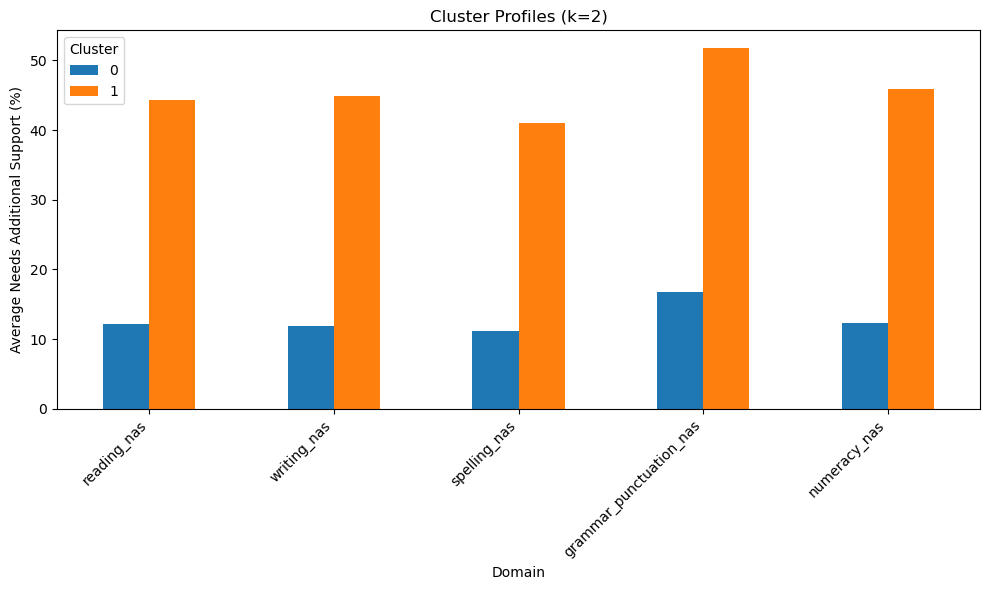

In [41]:
# Step 6:画图对比k=2和k=3
cluster_profile_k2.T.plot(kind="bar", figsize=(10, 6))
plt.title("Cluster Profiles (k=2)")
plt.ylabel("Average Needs Additional Support (%)")
plt.xlabel("Domain")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

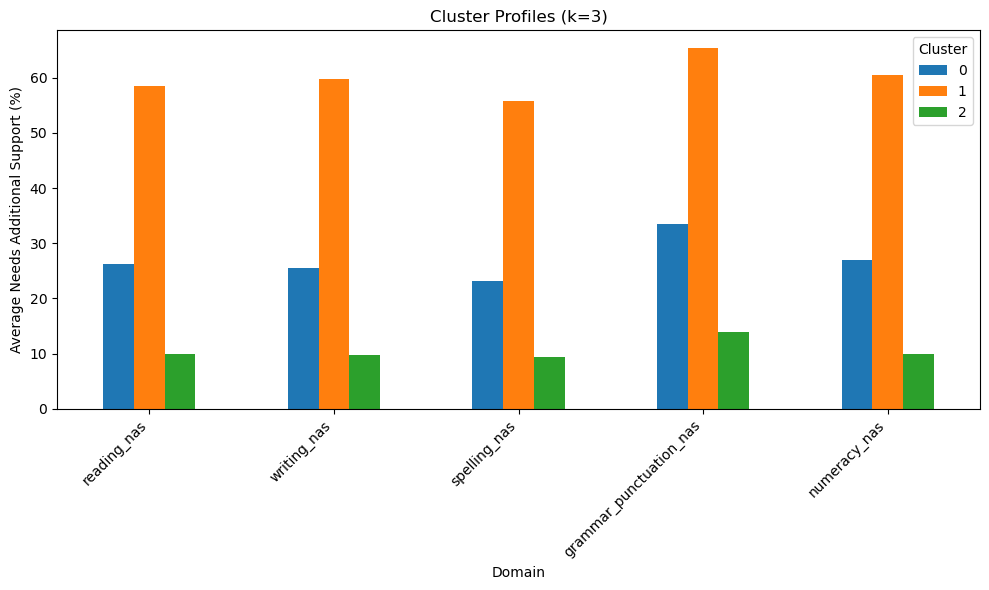

In [43]:
cluster_profile_k3.T.plot(kind="bar", figsize=(10, 6))
plt.title("Cluster Profiles (k=3)")
plt.ylabel("Average Needs Additional Support (%)")
plt.xlabel("Domain")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [45]:
# Step 7 :看cluster里有什么 subgroup
# Step 7.1:attribute中k=2时
for c in sorted(df_analysis["cluster_k2"].unique()):
    print(f"\ncluster_k2 = {c}")
    print(df_analysis[df_analysis["cluster_k2"] == c]["attribute"].value_counts())


cluster_k2 = 0
attribute
Parental education     564
Parental occupation    557
ABS remoteness         325
Gender                 192
Language background    190
Indigeneity            154
All                     93
Name: count, dtype: int64

cluster_k2 = 1
attribute
ABS remoteness         96
Parental education     83
Indigeneity            62
Parental occupation    61
Gender                 24
Language background    12
All                     1
Name: count, dtype: int64


In [47]:
# Step 7.2:attribute里k=3
for c in sorted(df_analysis["cluster_k3"].unique()):
    print(f"\ncluster_k3 = {c}")
    print(df_analysis[df_analysis["cluster_k3"] == c]["attribute"].value_counts())


cluster_k3 = 0
attribute
Parental education     186
Parental occupation    160
ABS remoteness         105
Indigeneity             91
Gender                  25
Language background      3
All                      1
Name: count, dtype: int64

cluster_k3 = 1
attribute
ABS remoteness         52
Parental occupation    34
Parental education     32
Indigeneity            16
Language background    12
Name: count, dtype: int64

cluster_k3 = 2
attribute
Parental education     429
Parental occupation    424
ABS remoteness         264
Gender                 191
Language background    187
Indigeneity            109
All                     93
Name: count, dtype: int64


In [49]:
# Step 7.3: year level,k=2
for c in sorted(df_analysis["cluster_k2"].unique()):
    print(f"\ncluster_k2 = {c}")
    print(df_analysis[df_analysis["cluster_k2"] == c]["year_level"].value_counts().sort_index())


cluster_k2 = 0
year_level
3    519
5    533
7    507
9    516
Name: count, dtype: int64

cluster_k2 = 1
year_level
3    91
5    78
7    87
9    83
Name: count, dtype: int64


In [51]:
# Step 7.4: year level,k=3
for c in sorted(df_analysis["cluster_k3"].unique()):
    print(f"\ncluster_k3 = {c}")
    print(df_analysis[df_analysis["cluster_k3"] == c]["year_level"].value_counts().sort_index())


cluster_k3 = 0
year_level
3    156
5    131
7    131
9    153
Name: count, dtype: int64

cluster_k3 = 1
year_level
3    38
5    32
7    41
9    35
Name: count, dtype: int64

cluster_k3 = 2
year_level
3    416
5    448
7    422
9    411
Name: count, dtype: int64


## Parent-Friendly Insights / 家长友好版解读

These visuals summarise Australian learning support patterns in a parent-friendly way.  
这些图表用更适合家长理解的方式，总结了澳大利亚学习支持需求的一些模式。

They help explain trends, not diagnose an individual child.  
这些内容是用来帮助理解整体趋势的，不是用来诊断某一个孩子的。

In [ ]:
# Parent-friendly card 1: reading and other learning areas
reading_links = corr_matrix.loc[
    ["writing_nas", "spelling_nas", "grammar_punctuation_nas", "numeracy_nas"],
    "reading_nas"
]

reading_labels = [
    "Writing",
    "Spelling",
    "Grammar & punctuation",
    "Numeracy"
]

reading_colors = ["#8FB9A8", "#A8C8E8", "#F2C57C", "#E07A5F"]

plt.figure(figsize=(9, 5))
bars = plt.barh(reading_labels, reading_links.values, color=reading_colors)
plt.xlim(0.9, 1.0)
plt.xlabel("Weaker relation                                Stronger relation")
plt.title("Reading difficulties often come with challenges in other learning areas\n\u9605\u8bfb\u56f0\u96be\u5e38\u5e38\u4f1a\u4f34\u968f\u5176\u4ed6\u5b66\u4e60\u9886\u57df\u7684\u56f0\u96be")
plt.grid(axis="x", linestyle="--", alpha=0.25)

for bar, value in zip(bars, reading_links.values):
    plt.text(value + 0.001, bar.get_y() + bar.get_height() / 2, f"{value:.2f}", va="center")

plt.tight_layout()
plt.show()

**Children needing extra reading support often also need support in writing, spelling, grammar, and numeracy.**  
**孩子在阅读上需要更多支持时，往往也会在写作、拼写、语法与标点、数学等学习领域需要帮助。**

In [ ]:
# Parent-friendly card 2: support need levels
support_profile = cluster_profile_k3.copy()
support_profile.index = ["Medium support needs", "Higher support needs", "Lower support needs"]
support_profile = support_profile.loc[["Lower support needs", "Medium support needs", "Higher support needs"]]

domain_labels = ["Reading", "Writing", "Spelling", "Grammar & punctuation", "Numeracy"]
domain_colors = ["#4C78A8", "#72B7B2", "#F2CF5B", "#F58518", "#E45756"]

ax = support_profile.plot(
    kind="bar",
    figsize=(11, 6),
    color=domain_colors,
    width=0.75
)
ax.set_title("Children do not all struggle in the same way\n\u4e0d\u540c\u5b69子\u9700要\u7684\u652f持\u7a0b\u5ea6\u5e76\u4e0d一\u6837")
ax.set_ylabel("Average extra support needed (%)")
ax.set_xlabel("")
ax.set_xticklabels(support_profile.index, rotation=0)
ax.legend(domain_labels, title="Learning areas", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

**Some children need occasional help, while others need consistent support across several areas.**  
**有些孩子只在少数情况下需要帮助，有些孩子则在多个学习领域持续需要支持。**

### Why this matters for parents / 为什么这对家长很重要

Reading difficulties may be linked with broader learning demands, not just one subject.  
阅读困难可能不只和单一学科有关，也可能与更广泛的学习负担相关。

Early understanding and support at home can reduce frustration and make reading practice feel safer.  
尽早理解孩子的阅读挑战，并在家庭中提供合适的支持，可以减少挫败感，让阅读练习更有安全感。

These insights are here to build understanding and empathy, not to diagnose a child.  
这些信息的目的是帮助家长更好地理解和共情，而不是用来诊断孩子。